# Lab Deep Learning/ Recurrent Neural Networks/ in pytorch

## Using Many-to-One for movie rating predicton

**Author: created by geoffroy.peeters@telecom-paris.fr** with the help of Stéphane Lathuilière

For any remark or suggestion, please feel free to contact me.

## Objective:
You will implement two different networks to perform the automatic rating (0 or 1) of movies given the text of their reviews.
You will use the ```imdb``` (internet movie database) dataset.

The reviews are already available in the form of indexes that point to a word dictionary: each word is already encoded as an index in the dictionary.

## Import packages

In [4]:
!pip install keras

In [5]:
from keras.datasets import imdb
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from argparse import Namespace

colab = True
student = True

## Parameters of the model

- We only consider the most used words in the word dictionary, we consider the top `param.n_word`
- We truncate/zero-pad each review to a length `param.T_x`

In [6]:
param = Namespace()

param.n_word = 5000 # --- input dimension
param.T_x = 100 # --- review length
param.index_word_from = 3 # --- indicate where the index start from (first index are used to indicate `PAD` `START` `UNK` tokens)

param.n_embedding = 32 # --- dimension of the embedding
param.n_lstm = 100 # --- dimension of the LSTM (for a<t> and c<t>)
param.n_out = 1 # --- binary classification problem

param.batch_size = 64
param.lr = 0.001
param.n_epoch = 8


## Import IMDB data

In [7]:
# --- Import the IMDB data and only consider the ``param.n_word``` most used words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=param.n_word, index_from=param.index_word_from )

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Data content

- ```X_train``` and ```X_test``` are each a numpy array, shape=(25000,), of lists.
  - Each list represent a review; it is a sequence (represented as a list) of indexes (position of each word in the dictionary)

- ```y_train``` and ```y_test``` are each a numpy array, shape=(25000,) of intergers.
  - Each integer represent the values 0 (bad movie) or 1 (good movie)

type(X_train): <class 'numpy.ndarray'>
number of training sequences: X_train.shape: (25000,)
type(X_train[0]): <class 'list'>
length of the first training sequence: len(X_train[0]): 218
length of the second training sequence: len(X_train[1]): 189
list of data of the first training sequence: X_train[0]: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 2, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 

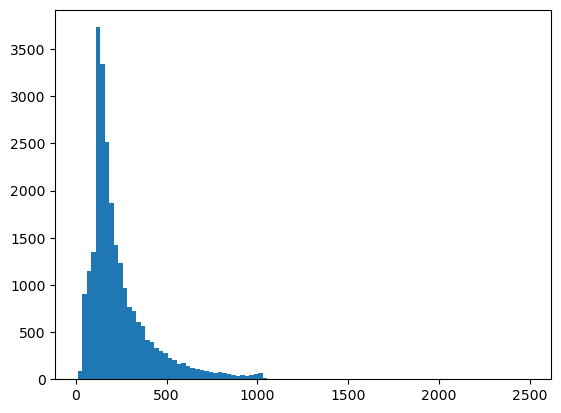

In [ ]:
print("type(X_train):", type(X_train))
print("number of training sequences: X_train.shape:", X_train.shape)
print("type(X_train[0]):", type(X_train[0]))
print("length of the first training sequence: len(X_train[0]):",len(X_train[0]))
print("length of the second training sequence: len(X_train[1]):",len(X_train[1]))
print("list of data of the first training sequence: X_train[0]:", X_train[0] )
len_list = [len(train) for train in X_train] 
print("maximum length of a training sequence:", max(len_list)) 

import matplotlib.pyplot as plt
plt.hist(len_list, 100);

## Details of how the reviews are encoded

In [ ]:
word_to_id = imdb.get_word_index() # --- get the dictionary mapping word to index
word_to_id = {key:(value+param.index_word_from) for key,value in word_to_id.items()} # --- shift the index by `param.index_word_from` to make room for `PAD` `START` `UNK` tokens 
word_to_id["<PAD>"] = 0
word_to_id["<START>"] = 1
word_to_id["<UNK>"] = 2

id_to_word = {value:key for key,value in word_to_id.items()} # --- get the dictionary mapping index to word
print(' '.join(id_to_word[id] for id in X_train[1000] )) # --- print the review of the 1000-th training sequence

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> although i had seen <UNK> in a theater way back in <UNK> i couldn't remember anything of the plot except for vague images of kurt thomas running and fighting against a backdrop of stone walls and disappointment regarding the ending br br after reading some of the other reviews i picked up a copy of the newly released dvd to once again enter the world of <UNK> br br it turns out this is one of those films produced during the <UNK> that would go directly to video today the film stars <UNK> <UNK> kurt thomas as jonathan <UNK> <UNK> out of the blue to <UNK> the nation of <UNK> to enter and hopefully win the game a <UNK> <UNK> <UNK> by the khan who <UNK> his people by yelling what sounds like <UNK> power the goal of the mission involves the star wars defense system jonathan is trained in the martial arts by princess <UNK> who never speaks or leaves the house once trained tries to blend in with the <UNK> by wearing a bright red <UNK> w

In [10]:
print("type(y_train):", type(y_train))
print("y_train.shape:", y_train.shape)
y_train[0]

type(y_train): <class 'numpy.ndarray'>
y_train.shape: (25000,)


np.int64(1)

In [11]:
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_test.shape: (25000,)
y_test.shape: (25000,)


## Data processing

Sequences (represented as a list of values) in `X_train` represent the reviews.
They can have different length $T_x$.
To train the network we should modify them so that they all have the same length `param.T_x`.

We do this by:
- **truncating** the ones that are too long,
- **padding-with-zeros** the ones that are too short.

This can be done at the start of the sequence (`pre`) or at the end (`post`).

In our use-case (rating of reviews), the decision ($\hat{y}$) is taken after reading the whole sentence/review ${x^{<t>}}$. Therefore we will truncate and pad-with-zeroes in `pre` mode (truncate the beginning of the sequence if too long, or add zeroes add the beggining of the sequence if too short).

In [12]:
def do_pad_sequences(sequences, required_len, truncating='pre', padding='pre'):
    """
    Parameters
    ----------
        sequences:  numpy arrays of lists, shape=(25000,)
        required_len:     required length of each sequence after truncating and padding
        padding     'pre' or 'post' mode
        truncating  'pre' or 'post' mode
    Returns
    -------
        padded_sequences    numpy arrays of lists (each list has now length maxlen)
    """
    if student:
        padded_sequences = []
        for seq in sequences:
            if len(seq) > required_len:
                if truncating == 'pre':
                    seq = seq[-required_len:]
                else:
                    seq = seq[:required_len]
            elif len(seq) < required_len:
                if padding == 'pre':
                    seq = [0] * (required_len - len(seq)) + seq
                else:
                    seq = seq + [0] * (required_len - len(seq))
            padded_sequences.append(seq)
        padded_sequences = np.array(padded_sequences)
    return padded_sequences


In [13]:
# --- truncate and pad input sequences
X_train = do_pad_sequences(X_train, required_len=param.T_x, padding='pre', truncating='pre')
X_test = do_pad_sequences(X_test, required_len=param.T_x, padding='pre', truncating='pre')

print("len(X_train[0]):", len(X_train[0]))
print("len(X_train[1]):", len(X_train[1]))
print("X_train[0]:", X_train[0])

len(X_train[0]): 100
len(X_train[1]): 100
X_train[0]: [1415   33    6   22   12  215   28   77   52    5   14  407   16   82
    2    8    4  107  117    2   15  256    4    2    7 3766    5  723
   36   71   43  530  476   26  400  317   46    7    4    2 1029   13
  104   88    4  381   15  297   98   32 2071   56   26  141    6  194
    2   18    4  226   22   21  134  476   26  480    5  144   30    2
   18   51   36   28  224   92   25  104    4  226   65   16   38 1334
   88   12   16  283    5   16 4472  113  103   32   15   16    2   19
  178   32]


# Define training and testing functions

In [14]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    """
    """

    model.train()
    total_loss, total_acc = 0, 0
    for X, y in data_loader:
        optimizer.zero_grad()
        hat_y = model(X)
        loss = criterion(hat_y.squeeze(), y)
        loss.backward() # --- SPECIFIC TO TRAINING
        optimizer.step() # --- SPECIFIC TO TRAINING

        total_loss += loss.item()
        predicted = (hat_y.squeeze() > 0.5).float()
        total_acc += (predicted == y).sum().item()/len(y)

    return total_loss/len(data_loader), total_acc/len(data_loader)



def test_one_epoch(model, data_loader, criterion):
    """
    """

    model.eval()
    total_loss, total_acc =  0, 0
    with torch.no_grad():
        for X, y in data_loader:
            hat_y = model(X)
            loss = criterion(hat_y.squeeze(), y)

            total_loss += loss.item()
            predicted = (hat_y.squeeze() > 0.5).float()
            total_acc += (predicted == y).sum().item()/len(y)

    return total_loss/len(data_loader), total_acc/len(data_loader)




def train(model, train_loader, test_loader, criterion, optimizer, n_epoch):
    """
    """

    for epoch in range(param.n_epoch):

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        print(f"Epoch {epoch + 1}, Loss: {train_loss }, Acc: {train_acc} ")

        test_loss, test_acc = test_one_epoch(model, test_loader, criterion)
        print(f"\tValidation Loss: {test_loss }, Acc: {test_acc} ")


In [15]:
# --- Convert numpy.array to torch.tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets for train and test data
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for train and test data
train_loader = DataLoader(train_dataset, batch_size=param.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=param.batch_size, shuffle=False)

# First model



In the first model, you will successively
- step-1) learn word embeddings $e^{<t>}$ of each item of the inut sequence $x^{(t)}$.
    - This is done by learning an embedding matrix $E$. You will use the `nn.Embedding` layer in pytorch.
    - In pytorch, the `nn.Embedding` layer does not really perform a matrix multiplication going from one-hot-encoding to embedding (it would be very costly to do that).
    - In pytorch `nn.Embedding` is a special layer that goes directly from index-of-the-word-in-the-dictionary to the embedding $e^{(t)}$
    - The embedding goes from `param.n_word` dimensions to  `param.n_embedding` dimensions
- step-2) compute the average over time $t$ of the embedding $e^{(t)}$ obtained for each word $x^{(t)}$ of a sequence (you should use `torch.mean`)
- step-3) apply a fully connected (`nn.linear` layer in pytorch) which output activation is a sigmoid (predicting the 0 or 1 rating)

<img src="https://perso.telecom-paristech.fr/gpeeters/doc/Lab_DL_RNN_01.png">



In [16]:
if student:
    # --- START CODE HERE (02)
    class SimpleModel(nn.Module):
        def __init__(self, param):
            super(SimpleModel, self).__init__()
            # Step-1: Embedding layer 
            # Maps from dictionary size (5000) to embedding size (32)
            self.embedding = nn.Embedding(param.n_word, param.n_embedding)
            
            self.fc = nn.Linear(param.n_embedding, param.n_out)
            
            self.activation = nn.Sigmoid()

        def forward(self, x):
            # 1. Get word embeddings
            e = self.embedding(x) # shape: (batch_size, T_x, n_embedding)
            
            # 2. Compute the average over time (dimension 1)
            # This condenses the review into a single "average sentiment" vector
            e_avg = torch.mean(e, dim=1) # shape: (batch_size, n_embedding)
            
            # 3. Apply the linear layer and sigmoid
            out = self.fc(e_avg)
            hat_y = self.activation(out)
            return hat_y


# --- Test
torch.manual_seed(0)
model = SimpleModel(param)
print(X_train_tensor[:param.batch_size, :].size())
print(model(X_train_tensor[:param.batch_size, :]).size())

torch.Size([64, 100])
torch.Size([64, 1])


In [17]:
# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),param.lr)

In [18]:
# Train the model
train(model, train_loader, test_loader, criterion, optimizer, param.n_epoch)

Epoch 1, Loss: 0.6747531953370175, Acc: 0.618486253196931 
	Validation Loss: 0.6472773244008994, Acc: 0.6908967391304348 
Epoch 2, Loss: 0.5944449586026809, Acc: 0.7352062020460358 
	Validation Loss: 0.5432630120335943, Acc: 0.7694213554987213 
Epoch 3, Loss: 0.48974179886186214, Acc: 0.7975863171355498 
	Validation Loss: 0.4584000352246072, Acc: 0.8072250639386189 
Epoch 4, Loss: 0.41904127041397193, Acc: 0.8285805626598466 
	Validation Loss: 0.41025567862688733, Acc: 0.8243286445012787 
Epoch 5, Loss: 0.3767482487441939, Acc: 0.8445812020460358 
	Validation Loss: 0.383270970124113, Acc: 0.8325207800511509 
Epoch 6, Loss: 0.3496507035039575, Acc: 0.8558583759590793 
	Validation Loss: 0.36714875294119503, Acc: 0.8377557544757033 
Epoch 7, Loss: 0.3303366076687108, Acc: 0.8615968670076726 
	Validation Loss: 0.3565715525842384, Acc: 0.842391304347826 
Epoch 8, Loss: 0.3154794947265664, Acc: 0.8678628516624042 
	Validation Loss: 0.34926891410747146, Acc: 0.8453884271099744 


## Results

After only 8 epochs, you should obtain an accuracy "around" 86.7%/ 84.5% for the test data.

## Using the trained embedding to find equivalence between words

Since the embedding is part of the models, we can look at the trained embedding matrix $E$ and use it to get the most similar words (according to the trained matrix $E$) in the dictionary.
You will use the weights of the `nn.Embedding` layer to find the most similar words to `great`. We will use an Euclidean distance for that.

- 1) Retrieve the weights of the `nn.Embedding` layer
- 2) Get the position of `great` in the dictionary
- 3) Knowing this position, get the word-embedding of `great`
- 4) Find (using Euclidean distance), the closest embedded-words to `great`

Remarks:
- you can access a specific layer of the model by using the name you used to define `self.??? = nn.Embedding` in the `__init__`method of `SimpleModel`.
- be careful about the order of the dimensions of the embedding matrix `E`

In [19]:
if student:
    # --- START CODE HERE (03)
    E = model.embedding.weight.detach()
    word_target = "great"
    idx_target = word_to_id[word_target]
    v_target = E[idx_target]
    distances = torch.norm(E - v_target, dim=1)
    closest_distances, closest_indices = torch.topk(distances, k=6, largest=False)

    print(f"Words closest to '{word_target}':")
    for i in range(len(closest_indices)):
        word = id_to_word[closest_indices[i].item()]
        dist = closest_distances[i].item()
        print(f"{i}: {word} (distance: {dist:.4f})")
    



Words closest to 'great':
0: great (distance: 0.0000)
1: fun (distance: 6.3990)
2: masterpiece (distance: 6.5137)
3: excellent (distance: 6.7370)
4: friendship (distance: 6.9951)
5: definite (distance: 7.2949)


# Second model

In the second model, you will replace step-2 (which was "compute the average over time $t$ of the embedding $e^{(t)}$") by a RNN layer over time.
More precisely you will use a LSTM (`nn.LSTM` layer in pytorch) with `param.n_lstm=100` units (or dimensions) in a Many-To-One configuration

Don't forget that in ou data, the first dimension of `X_train/X_test` represents the batch (`batch_first=True` in pytorch).



In [21]:
if student:
    
    class LstmModel(nn.Module):
        def __init__(self, param):
            super(LstmModel, self).__init__()
            self.embedding = nn.Embedding(param.n_word, param.n_embedding)
            self.lstm = nn.LSTM(input_size=param.n_embedding, hidden_size=param.n_lstm, batch_first=True)
            self.fc = nn.Linear(param.n_lstm, param.n_out)
            self.activation = nn.Sigmoid()
        def forward(self, x):
            e = self.embedding(x) # shape: (batch_size, T_x, n_embedding)
            lstm_out, (h_n, c_n) = self.lstm(e) # lstm_out shape: (batch_size, T_x, n_lstm)
            h_T = h_n[-1] # shape: (batch_size, n_lstm)
            out = self.fc(h_T)
            hat_y = self.activation(out)
            return hat_y
    


# --- Test
torch.manual_seed(0)
model = LstmModel(param)
print(X_train_tensor[:param.batch_size, :].size())
print(model(X_train_tensor[:param.batch_size, :]).size())

torch.Size([64, 100])
torch.Size([64, 1])


In [22]:
# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), param.lr)

In [23]:
# Train the model
train(model, train_loader, test_loader, criterion, optimizer, param.n_epoch)

Epoch 1, Loss: 0.6336732765902644, Acc: 0.6224104859335039 
	Validation Loss: 0.55463612437858, Acc: 0.7132592710997442 
Epoch 2, Loss: 0.4874729088047886, Acc: 0.7648497442455242 
	Validation Loss: 0.4434418916854712, Acc: 0.794693094629156 
Epoch 3, Loss: 0.39420336168592846, Acc: 0.8239290281329923 
	Validation Loss: 0.43406341261113696, Acc: 0.7982496803069055 
Epoch 4, Loss: 0.3514142458319969, Acc: 0.8460517902813298 
	Validation Loss: 0.3705947192200005, Acc: 0.8347666240409207 
Epoch 5, Loss: 0.3073325232814645, Acc: 0.8720428388746803 
	Validation Loss: 0.37994875452097726, Acc: 0.8397298593350384 
Epoch 6, Loss: 0.27759762546595407, Acc: 0.8857976342710998 
	Validation Loss: 0.37342715960786776, Acc: 0.8432065217391305 
Epoch 7, Loss: 0.24150509293884267, Acc: 0.9025335677749361 
	Validation Loss: 0.39294274921155037, Acc: 0.8462595907928389 
Epoch 8, Loss: 0.2186484970057102, Acc: 0.9140984654731459 
	Validation Loss: 0.40816705138482096, Acc: 0.8483296035805626 


## Results

After only 8 epochs, you should obtain an accuracy around 91.1%/ 84.7% for the test data.

# Evaluation

To evaluate the work, you should rate the code for
- 1) Data Pre-Processing (01)
- 2) Simple model  (02)
- 3) Find equivalence between words (03)
- 4) LSTM model (04)
